# Flower Image Classification using Deep Learning

## Overview

This project builds an image classification model to identify 102 flower categories using the Oxford Flowers dataset. The workflow includes data preprocessing, model training, evaluation, and prediction.

A pretrained MobileNetV2 model is used and fine tuned for this multi class classification task.

### Objectives

- Preprocess and load image data  
- Train a deep learning classification model  
- Evaluate model performance  
- Perform predictions on new images  

### Scope

Focus is on building and understanding the end to end model pipeline. Future improvements can include model tuning and deployment.

In [1]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Standard libraries
import random
import time
import numpy as np
import matplotlib.pyplot as plt

# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Torchvision (datasets, transforms, models)
from torchvision import datasets, transforms, models

from torchvision.datasets import Flowers102

In [2]:
# Configure logging (suppress unnecessary logs)
import logging

logger = logging.getLogger(__name__)
logger.setLevel(logging.ERROR)

# Check PyTorch version
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.11.0


## Data Loading

The [Oxford Flowers 102](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.Flowers102.html) dataset is loaded using PyTorch utilities and split into `training`, `validation`, and `test` sets.

All images are resized to `224 × 224` and normalized to match the input requirements of pretrained models.

The `training` set is used for model training, while the `validation` and `test` sets are used for evaluation.

In [3]:
# Define image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to model input size
    transforms.ToTensor()           # Convert images to tensor
])

# Load datasets
training_set = Flowers102(
    root="data",
    split="train",
    transform=transform,
    download=True
)

validation_set = Flowers102(
    root="data",
    split="val",
    transform=transform,
    download=True
)

test_set = Flowers102(
    root="data",
    split="test",
    transform=transform,
    download=True
)

## Data Exploration

The dataset is explored to understand its size and structure. This step ensures that the data is loaded correctly and ready for training.

In [4]:
# Store datasets in a dictionary for easy access
datasets = {
    "train": training_set,
    "val": validation_set,
    "test": test_set
}

# Display number of samples in each split
for name, dataset in datasets.items():
    print(f"{name} samples: {len(dataset)}")

# Total training samples
total_samples = len(training_set)

train samples: 1020
val samples: 1020
test samples: 6149


In [5]:
# Get number of classes from the dataset
num_classes = len(training_set.classes)

print(f"Number of classes: {num_classes}")

Number of classes: 102


### Normalization

Images are normalized to scale pixel values and make training more stable.

The normalization values used are:

- Mean: [0.485, 0.456, 0.406]  
- Standard deviation: [0.229, 0.224, 0.225]

These values are computed from the ImageNet dataset by calculating the average and variation of pixel values for each color channel (Red, Green, Blue) across a large number of images.

Pretrained models like MobileNetV2 are trained on ImageNet, so using the same normalization ensures that the input data matches what the model expects, leading to better and more stable performance.

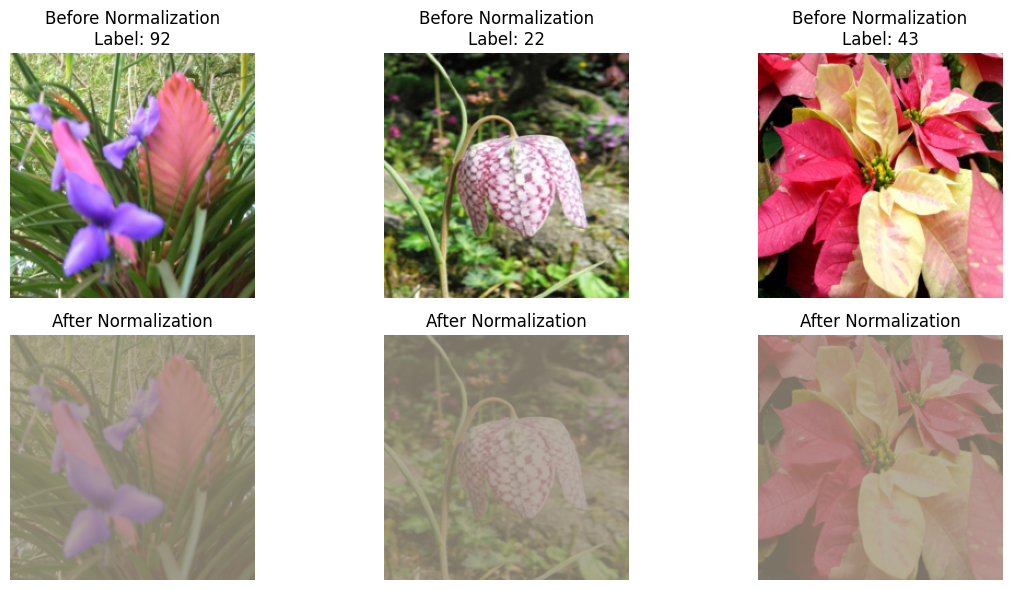

In [6]:
# Compare images before and after normalization (display corrected)
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

indices = random.sample(range(len(training_set)), 3)

# ImageNet normalization values
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i, idx in enumerate(indices):
    image, label = training_set[idx]

    # Convert tensor to numpy (H, W, C)
    image_np = image.permute(1, 2, 0).numpy()

    # Top row: before normalization (as loaded)
    axes[0, i].imshow(image_np)
    axes[0, i].set_title(f"Before Normalization\nLabel: {label}")
    axes[0, i].axis("off")

    # Bottom row: after normalization (corrected for display)
    image_denorm = image_np * std + mean
    image_denorm = np.clip(image_denorm, 0, 1)

    axes[1, i].imshow(image_denorm)
    axes[1, i].set_title("After Normalization")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## Label Mapping

The dataset provides labels as numeric values, where each number corresponds to a specific flower category. To make these labels understandable, a mapping is used to convert numeric labels into actual flower names.

This mapping is stored in a JSON file (`label_map.json`) and is loaded using the Python `json` module. The file is read and converted into a dictionary, where each key represents a label index and the value represents the corresponding flower name.

Using this mapping allows the model predictions and visualizations to display meaningful class names instead of numeric labels, making the results easier to interpret.

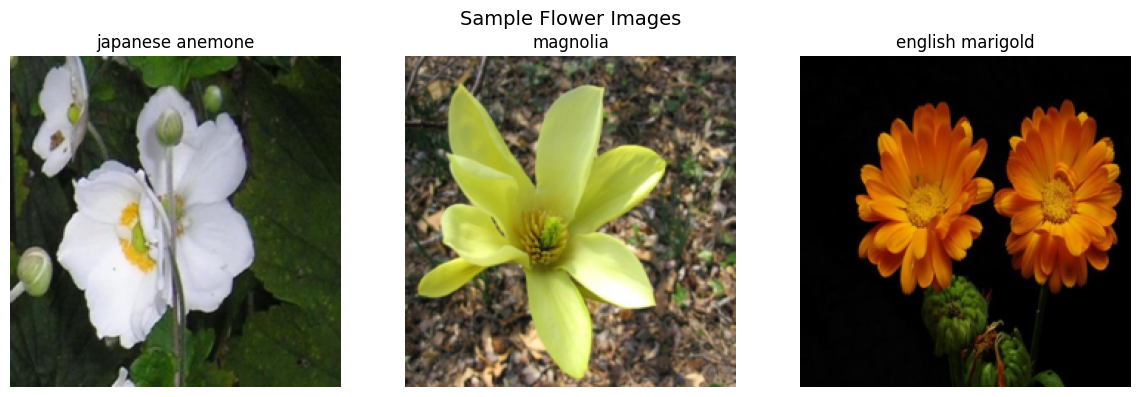

In [7]:
# Load label mapping
import json

with open("label_map.json", "r") as f:
    class_names = json.load(f)

# Display sample images with class names
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

indices = random.sample(range(len(training_set)), 3)

for i, idx in enumerate(indices):
    image, label = training_set[idx]

    image_np = image.permute(1, 2, 0).numpy()

    # Labels in dataset start from 0, mapping uses 1-based indexing
    class_name = class_names[str(label + 1)]

    axes[i].imshow(image_np)
    axes[i].set_title(class_name)
    axes[i].axis("off")

fig.suptitle("Sample Flower Images", fontsize=14)

plt.tight_layout()
plt.show()

## Data Pipeline

In this step, a data pipeline is created to load the dataset in batches for training. This improves training efficiency and allows better memory management when working with large datasets.

PyTorch DataLoader is used to handle batching, shuffling, and data loading during training.

The training dataset is shuffled to ensure better learning and generalization, while the validation and test datasets are not shuffled to maintain consistent evaluation.

In [8]:
# Batch size
batch_size = 32

# Number of training samples
num_training_examples = len(training_set)
print(f"Training samples: {num_training_examples}")

# Create data loaders
training_batches = DataLoader(training_set, batch_size=batch_size, shuffle=True)
validation_batches = DataLoader(validation_set, batch_size=batch_size, shuffle=False)
testing_batches = DataLoader(test_set, batch_size=batch_size, shuffle=False)

Training samples: 1020


## Model Training

Now that the data pipeline is ready, a classifier is built and trained using a pretrained model. Instead of training a model from scratch, a pretrained MobileNet model from PyTorch is used and fine tuned for this task.

The main steps involved are:

- Load a pretrained MobileNet model  
- Freeze the feature extraction layers  
- Replace the final layer with a new classifier  
- Train the classifier on the flower dataset  
- Monitor training and validation performance  
- Save the trained model  

During training, only the final classifier layer is updated while the rest of the model remains fixed. This reduces training time and allows the model to learn effectively from a smaller dataset.

In [9]:
# Load pretrained MobileNetV2 model
model = models.mobilenet_v2(pretrained=True)

# Freeze feature extractor layers
for param in model.features.parameters():
    param.requires_grad = False

# Replace final classifier layer for current task
model.classifier[1] = nn.Linear(model.last_channel, num_classes)

In [10]:
# Display model architecture and parameter details
from torchinfo import summary

summary(model, input_size=(32, 3, 224, 224))

Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV2                                        [32, 102]                 --
├─Sequential: 1-1                                  [32, 1280, 7, 7]          --
│    └─Conv2dNormActivation: 2-1                   [32, 32, 112, 112]        --
│    │    └─Conv2d: 3-1                            [32, 32, 112, 112]        (864)
│    │    └─BatchNorm2d: 3-2                       [32, 32, 112, 112]        (64)
│    │    └─ReLU6: 3-3                             [32, 32, 112, 112]        --
│    └─InvertedResidual: 2-2                       [32, 16, 112, 112]        --
│    │    └─Sequential: 3-4                        [32, 16, 112, 112]        (896)
│    └─InvertedResidual: 2-3                       [32, 24, 56, 56]          --
│    │    └─Sequential: 3-5                        [32, 24, 56, 56]          (5,136)
│    └─InvertedResidual: 2-4                       [32, 24, 56, 56]          --
│    │    └─Sequential

In [11]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Check GPU availability
print(f"Is GPU available: {torch.cuda.is_available()}")
print(f"Using device: {device}")

Is GPU available: False
Using device: cpu


In [12]:
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters())

train_losses = []
val_losses = []
val_accuracies = []

EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for images, labels in tqdm(training_batches, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Average training loss
    train_loss /= len(training_batches)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in validation_batches:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    # Average validation loss
    val_loss /= len(validation_batches)
    val_losses.append(val_loss)

    val_acc = correct / total
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1/5: 100%|██████████| 32/32 [00:49<00:00,  1.54s/it]


Epoch 1 | Train Loss: 4.4150 | Val Loss: 3.3448 | Val Acc: 0.3853


Epoch 2/5: 100%|██████████| 32/32 [00:52<00:00,  1.64s/it]


Epoch 2 | Train Loss: 2.4546 | Val Loss: 2.1715 | Val Acc: 0.6716


Epoch 3/5: 100%|██████████| 32/32 [00:53<00:00,  1.68s/it]


Epoch 3 | Train Loss: 1.3952 | Val Loss: 1.5859 | Val Acc: 0.7637


Epoch 4/5: 100%|██████████| 32/32 [00:54<00:00,  1.71s/it]


Epoch 4 | Train Loss: 0.8714 | Val Loss: 1.2763 | Val Acc: 0.8235


Epoch 5/5: 100%|██████████| 32/32 [00:56<00:00,  1.76s/it]


Epoch 5 | Train Loss: 0.5824 | Val Loss: 1.0911 | Val Acc: 0.8284


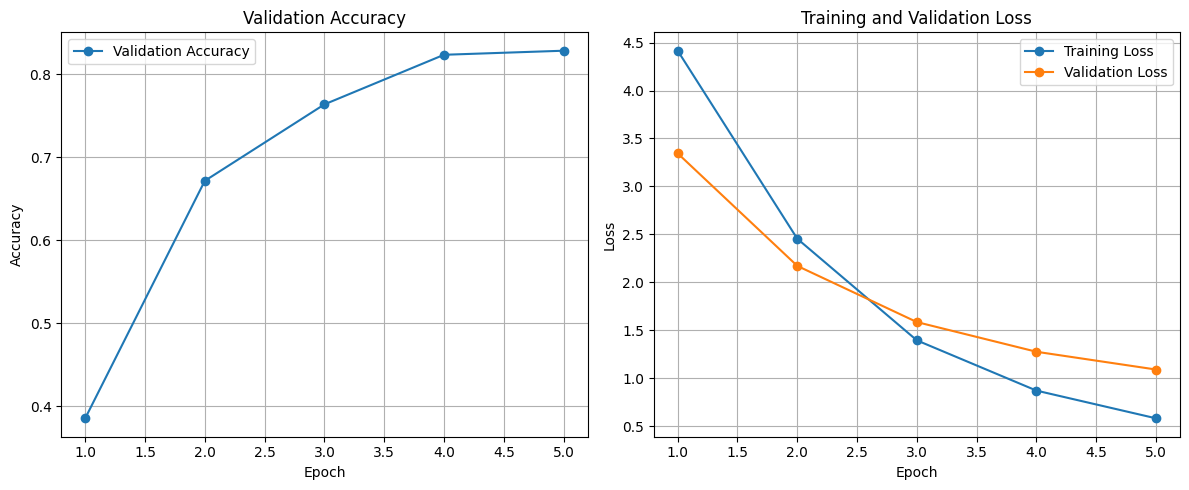

In [13]:
# Plot training results
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Validation Accuracy
axes[0].plot(epochs_range, val_accuracies, marker='o', label="Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Validation Accuracy")
axes[0].grid(True)
axes[0].legend()

# Training and Validation Loss
axes[1].plot(epochs_range, train_losses, marker='o', label="Training Loss")
axes[1].plot(epochs_range, val_losses, marker='o', label="Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Training and Validation Loss")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

## Model Evaluation

After training, the model is evaluated on the test dataset. This dataset contains images that were not used during training or validation.

Evaluation on the test set provides a measure of how well the model generalizes to new, unseen data.

A well performing model is expected to achieve around 70% accuracy on the test dataset.

In [14]:
# Evaluate model on test set
model.eval()
test_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testing_batches:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

# Average test loss
test_loss /= len(testing_batches)

# Compute accuracy
test_accuracy = correct / total

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.3%}")


Test Loss: 1.1552
Test Accuracy: 81.786%


In [15]:
# Print test results
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.3%}")


Test Loss: 1.1552
Test Accuracy: 81.786%


## Save the Model

After training, the model is saved so it can be loaded later for inference or further use.

In PyTorch, the recommended approach is to save the model's state dictionary. This stores only the learned parameters instead of the entire model, making it more efficient and flexible.

Saving the state dictionary allows the model to be reloaded later with the same architecture and weights.

In [16]:
# Define model save path
model_path = "flower_model.pth"

# Save only the trained model parameters (state dictionary)
torch.save(model.state_dict(), model_path)

# Confirm save location
print(f"Model saved to: {model_path}")

Model saved to: flower_model.pth


## Load the Model

In this step, the saved model is loaded so it can be used for inference or further evaluation.

The model architecture is first defined, and then the saved state dictionary is loaded into it. This restores the learned parameters and allows the model to make predictions on new data.

In [17]:
# Load saved model parameters
model.load_state_dict(torch.load(model_path, map_location=device))

# Move model to device
model = model.to(device)

# Set model to evaluation mode
model.eval()

# Display model summary
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV2                                        [1, 102]                  --
├─Sequential: 1-1                                  [1, 1280, 7, 7]           --
│    └─Conv2dNormActivation: 2-1                   [1, 32, 112, 112]         --
│    │    └─Conv2d: 3-1                            [1, 32, 112, 112]         (864)
│    │    └─BatchNorm2d: 3-2                       [1, 32, 112, 112]         (64)
│    │    └─ReLU6: 3-3                             [1, 32, 112, 112]         --
│    └─InvertedResidual: 2-2                       [1, 16, 112, 112]         --
│    │    └─Sequential: 3-4                        [1, 16, 112, 112]         (896)
│    └─InvertedResidual: 2-3                       [1, 24, 56, 56]           --
│    │    └─Sequential: 3-5                        [1, 24, 56, 56]           (5,136)
│    └─InvertedResidual: 2-4                       [1, 24, 56, 56]           --
│    │    └─Sequential

## Inference

In this step, the trained model is used to make predictions on new images.

The input image is preprocessed in the same way as the training data to ensure consistency. It is then passed through the model to obtain predicted classes along with their probabilities.

The top predicted classes are selected based on the highest probabilities.

In [18]:
from PIL import Image

def process_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = image.resize((224, 224))
    
    # Convert to numpy and scale to [0, 1]
    image = np.array(image) / 255.0

    # Normalize using ImageNet values
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = (image - mean) / std

    # Convert to tensor and rearrange dimensions (C, H, W)
    image = torch.from_numpy(image).permute(2, 0, 1).float()

    # Add batch dimension (1, C, H, W)
    image = image.unsqueeze(0)

    return image

## Image Preprocessing Check

In this step, the image preprocessing function is verified to ensure it works correctly.

The original image is compared with the processed image to confirm that it is properly resized and formatted before being passed to the model.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8044444..2.0].


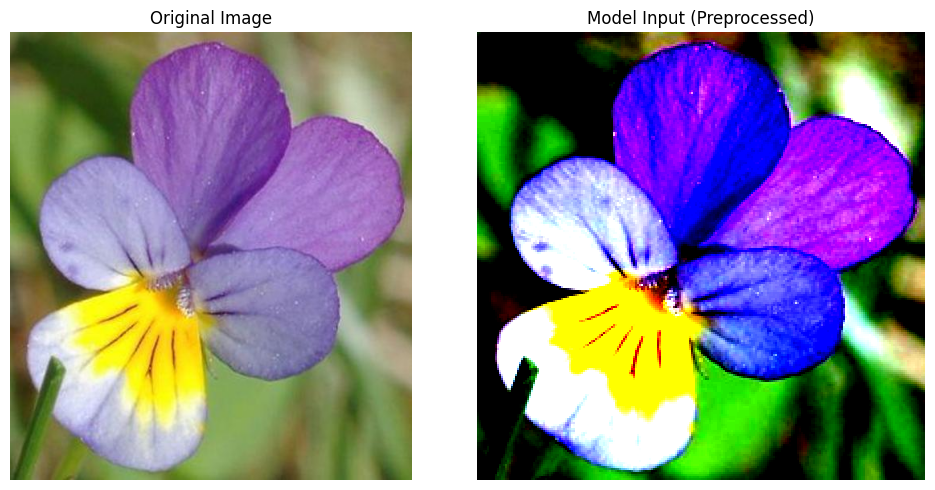

In [19]:
# Load original image
image_path = './test_images/wild_pansy.jpg'
original_image = np.array(Image.open(image_path).convert("RGB"))

# Process image (for model)
processed_image = process_image(image_path)

# Convert processed image for display (no denormalization)
image_np = processed_image.squeeze().permute(1, 2, 0).numpy()

# Clip values for safe display
image_np = np.clip(image_np, -2, 2)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(original_image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(image_np)
axes[1].set_title("Model Input (Preprocessed)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Inference

The processed image is passed to the trained model to generate predictions.

The model outputs probability values for each class, indicating how likely the image belongs to each category.

The top K classes with the highest probabilities are selected and returned along with their corresponding class labels.

In [20]:
def predict(image_path, model, top_k=5):
    if top_k < 1:
        top_k = 1

    model.eval()

    # Process image (already returns correct tensor)
    image = process_image(image_path).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)

    top_probs, top_classes = probs.topk(top_k)

    return top_probs.squeeze().cpu().numpy(), top_classes.squeeze().cpu().numpy()

## Sanity Check

After making predictions, the model is tested on sample images to verify that it is working correctly.

The input image is displayed along with the top predicted classes and their probabilities.

The probabilities are visualized using a bar chart to show the model's confidence for each prediction. Class labels are converted to flower names for better interpretation.

In [21]:
images = [
    'cautleya_spicata.jpg',
    'hard-leaved_pocket_orchid.jpg',
    'orange_dahlia.jpg',
    'wild_pansy.jpg'
]

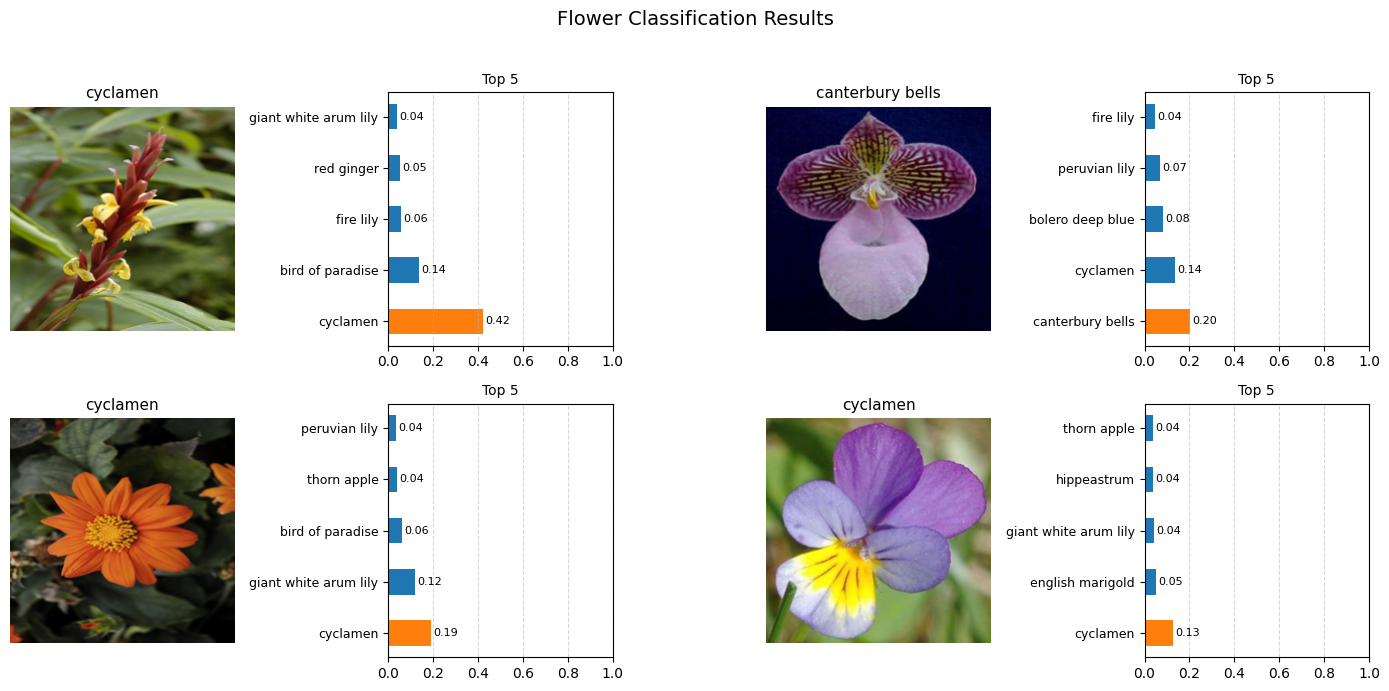

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, img in enumerate(images):
    path = f'./test_images/{img}'

    # Get predictions
    probs, classes = predict(path, model, 5)

    # Get image for display (denormalized)
    image = process_image(path)
    image = image.squeeze().permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    # Map class indices to names
    flower_names = [class_names[str(c + 1)] for c in classes]

    row = i // 2
    col = (i % 2) * 2

    # Show image
    axes[row, col].imshow(image)
    axes[row, col].axis("off")
    axes[row, col].set_title(flower_names[0], fontsize=11)

    # Reverse for bar chart (lowest → highest)
    probs_rev = probs[::-1]
    names_rev = flower_names[::-1]

    # Highlight top prediction
    colors = ["tab:blue"] * 5
    colors[-1] = "tab:orange"

    # Bar chart
    axes[row, col + 1].barh(range(5), probs_rev, color=colors, height=0.5)
    axes[row, col + 1].set_yticks(range(5))
    axes[row, col + 1].set_yticklabels(names_rev, fontsize=9)
    axes[row, col + 1].set_xlim(0, 1)
    axes[row, col + 1].invert_yaxis()
    axes[row, col + 1].set_title("Top 5", fontsize=10)

    # Show probability values
    for j, v in enumerate(probs_rev):
        axes[row, col + 1].text(v + 0.01, j, f"{v:.2f}", va='center', fontsize=8)

    axes[row, col + 1].grid(axis='x', linestyle='--', alpha=0.5)

fig.suptitle("Flower Classification Results", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("predictions_grid.png", dpi=300)
plt.show()